# Unrestricted Hartree Fock Challenges
This notebook will exemplify some issues in the development of the UHF and what/how fixes were implemented.

In [1]:
from pyscf import gto, scf
import numpy as np
from py_mods.src.SCF.CSUHF import CS_UHF
from py_mods.src.SCF.types import CSUHFContext
from py_mods.src.SCF.plot_utilities import plot_map
import matplotlib.pyplot as plt

## Incorrect Li SCF convergence
This example shows how a flawed guess can lead to errors. In this particular case, with a $H_{core}$ guess, the DIIS gets stuck in an incorrect minimum, and converges to a wrong state. However, if we let the regular SCF continue direvtly it bounces to the correct minimum.

In [2]:
# pyscf data
mol_He = gto.M(atom="  Li 0 0 0; ", spin=1, charge=0, basis="aug-cc-pvqz")

kin = mol_He.intor("int1e_kin")
vnuc = mol_He.intor("int1e_nuc")
overlap = mol_He.intor("int1e_ovlp")
eri = mol_He.intor("int2e")

rhf_He = scf.UHF(mol_He)

e_He = rhf_He.kernel()
e_elec = rhf_He.energy_elec()

print(e_elec)

converged SCF energy = -7.43271871704645  <S^2> = 0.75001472  2S+1 = 2.0000147
(np.float64(-7.43271871704645), np.float64(2.2810037415636337))


In [3]:
# Preparation of the context and calculation
Li_context = CSUHFContext(overlap, kin, vnuc, eri, n_electrons=3)
Li_context.max_iter = 300
Li_context.conv_type = "DIIS"
Li_context.p_guess = "core"
Li_context.verbose = True
Li_context.threshold = 1e-12

In [4]:
# Li_UHF_results = CS_UHF(Li_context)
# print(f"Converged: {Li_UHF_results.converged} in {Li_UHF_results.iterations}")
# print(f"Final energy: {Li_UHF_results.E_UHF}")
# print(f"Error in Final energy: {Li_UHF_results.E_UHF-e_elec[0]}")

Which is not correct, as it has converged to an incorrect minimum. To fix this problem, we have introduced a RHF guess, that generates a RHF of this system or the cation (to have even electrons) and then starts the UHF calculation from this density:

In [5]:
# Li_context.p_guess = "RHF"
# Li_correct_UHF_results = CS_UHF(Li_context)
# print(
#     f"Converged: {Li_correct_UHF_results.converged} in {Li_correct_UHF_results.iterations}"
# )
# print(f"Final energy: {Li_correct_UHF_results.E_UHF}")
# print(f"Error in Final energy: {Li_correct_UHF_results.E_UHF-e_elec[0]}")

# Dissociations 
A simple dissociation. Chose atoms, basis and number of electrons here:  

In [6]:
# change here to see different curves.
n_points =  60
element_1 = "H"
element_2 = "H"
basis = "aug-cc-pvdz"
n_elec = 2
distances = np.linspace(0.3, 30, n_points)

In [7]:
RHF_eners = np.zeros_like(distances)
for i, dist in enumerate(distances):
    mol_He = gto.M(
        atom=f"  {element_1} 0 0 0; {element_2} {dist} 0 0",
        spin=0,
        charge=0,
        basis=basis,
    )

    kin = mol_He.intor("int1e_kin")
    vnuc = mol_He.intor("int1e_nuc")
    overlap = mol_He.intor("int1e_ovlp")
    eri = mol_He.intor("int2e")

    rhf_He = scf.RHF(mol_He)

    e_He = rhf_He.kernel()
    e_elec = rhf_He.energy_elec()

    RHF_eners[i] = e_elec[0]

converged SCF energy = -0.615684850088791
converged SCF energy = -1.12689229244495
converged SCF energy = -1.0405993205034
converged SCF energy = -0.951812413378257
converged SCF energy = -0.88838053864101
converged SCF energy = -0.845245346127748
converged SCF energy = -0.816102604961343
converged SCF energy = -0.796301857258499
converged SCF energy = -0.782690278805533
converged SCF energy = -0.773112370802543
converged SCF energy = -0.766126101487939
converged SCF energy = -0.760820646369533
converged SCF energy = -0.756636439640892
converged SCF energy = -0.753229824497065
converged SCF energy = -0.750386199411421
converged SCF energy = -0.747966059968328
converged SCF energy = -0.745873755434551
converged SCF energy = -0.744040856434584
converged SCF energy = -0.742417247185024
converged SCF energy = -0.740965723988362
converged SCF energy = -0.739658261793442
converged SCF energy = -0.738473316402998
converged SCF energy = -0.737393913338305
converged SCF energy = -0.736406343434

In [8]:
UHF_eners = np.zeros_like(distances)
for i, dist in enumerate(distances):
    mol = gto.M(
        atom=f"  {element_1} 0 0 0; {element_2} {dist} 0 0",
        spin=0,
        charge=0,
        basis=basis,
    )

    mf = scf.UHF(
        mol,
    )

    dm_alpha, dm_beta = mf.get_init_guess()

    e_He = mf.kernel()
    e_elec = mf.energy_elec()

    UHF_eners[i] = e_elec[0]

converged SCF energy = -0.615684850089086  <S^2> = -4.4408921e-16  2S+1 = 1
converged SCF energy = -1.12689229244483  <S^2> = 2.5401903e-13  2S+1 = 1
converged SCF energy = -1.04059932050349  <S^2> = 3.4039438e-13  2S+1 = 1
converged SCF energy = -0.951812413378301  <S^2> = 2.3774316e-12  2S+1 = 1
converged SCF energy = -0.888380538615733  <S^2> = 1.6450241e-10  2S+1 = 1
converged SCF energy = -0.845245346124265  <S^2> = 2.5389912e-11  2S+1 = 1
converged SCF energy = -0.81610260495981  <S^2> = 1.4505508e-11  2S+1 = 1
converged SCF energy = -0.796301857258063  <S^2> = 4.5654591e-12  2S+1 = 1
converged SCF energy = -0.782690278805303  <S^2> = 2.5612845e-12  2S+1 = 1
converged SCF energy = -0.773112370802376  <S^2> = 1.9155788e-12  2S+1 = 1
converged SCF energy = -0.766126101487803  <S^2> = 1.5711876e-12  2S+1 = 1
converged SCF energy = -0.760820646369437  <S^2> = 1.1015633e-12  2S+1 = 1
converged SCF energy = -0.756636439640684  <S^2> = 2.3392399e-12  2S+1 = 1
converged SCF energy = -0.7

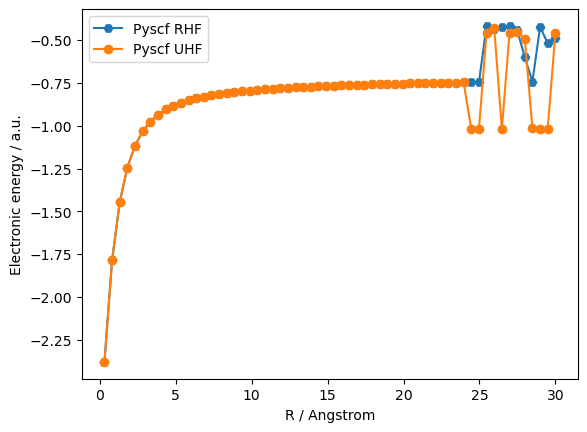

In [9]:
plt.plot(distances, RHF_eners, label="Pyscf RHF", marker="H")
plt.plot(distances, UHF_eners, label="Pyscf UHF", marker="o")
plt.xlabel("R / Angstrom")
plt.ylabel("Electronic energy / a.u.")
plt.legend()
plt.show()

And we can see that there is no notable difference. This is because it is necessary to break the symmetry of the alpha and beta density matrices. This is done by setting to zero the beta density of the 1s and 2s orbitals in the H case. 

In [10]:
UHF_eners = np.zeros_like(distances)
for i, dist in enumerate(distances):
    mol = gto.M(
        atom=f"  {element_1} 0 0 0; {element_2} {dist} 0 0",
        spin=0,
        charge=0,
        basis=basis,
    )

    kin = mol_He.intor("int1e_kin")
    vnuc = mol_He.intor("int1e_nuc")
    overlap = mol_He.intor("int1e_ovlp")
    eri = mol_He.intor("int2e")

    mf = scf.UHF(
        mol,

        
    )

    dm_alpha, dm_beta = mf.get_init_guess()
    dm_beta[:n_elec, :n_elec] = 0
    dm = (dm_alpha, dm_beta)

    e_He = mf.kernel(
        dm,
    )
    e_elec = mf.energy_elec()

    UHF_eners[i] = e_elec[0]

converged SCF energy = -0.615684850088436  <S^2> = 1.582956e-12  2S+1 = 1
converged SCF energy = -1.12689229244489  <S^2> = 3.2485126e-13  2S+1 = 1
converged SCF energy = -1.04290915183871  <S^2> = 0.23836986  2S+1 = 1.3976693
converged SCF energy = -1.00675568440631  <S^2> = 0.830233  2S+1 = 2.0786852
converged SCF energy = -1.00015749698234  <S^2> = 0.96085076  2S+1 = 2.2007733
converged SCF energy = -0.998952109372209  <S^2> = 0.99097184  2S+1 = 2.2279783
converged SCF energy = -0.998722621438546  <S^2> = 0.99795126  2S+1 = 2.2342348
converged SCF energy = -0.998679490378533  <S^2> = 0.99954697  2S+1 = 2.2356627
converged SCF energy = -0.998672195725583  <S^2> = 0.99990296  2S+1 = 2.2359812
converged SCF energy = -0.99866986965493  <S^2> = 0.99997997  2S+1 = 2.2360501
converged SCF energy = -0.998668959241757  <S^2> = 0.99999601  2S+1 = 2.2360644
converged SCF energy = -0.99866876874066  <S^2> = 0.99999921  2S+1 = 2.2360673
converged SCF energy = -0.998668704187294  <S^2> = 0.999999

And we can see that there is a difference in the dissociation curve, as one would expect in the unrestricted case. 

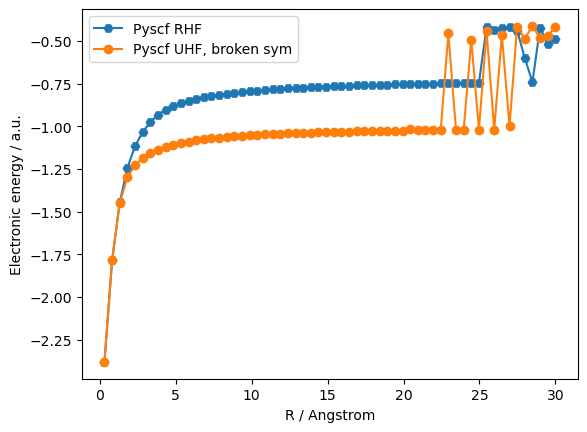

In [11]:
plt.plot(distances, RHF_eners, label="Pyscf RHF", marker="H")
plt.plot(distances, UHF_eners, label="Pyscf UHF, broken sym", marker="o")
plt.xlabel("R / Angstrom")
plt.ylabel("Electronic energy / a.u.")
plt.legend()
plt.show()

However, up to now, the guess for the SCF has been to use the core Hamiltonian. Using this approach directly results in no symmetry breaking, as the density matrix is composed of zeros in the guess. 

Therefore, in order to be able to break the symmetry, it is necessary a non-zero guess. In the current implementation here, we combine the RHF and UHF to start with a few iterations of the RHF in order to get a better guess of the density and then start the UHF loop from this density. 

We will compare now the densities between the pyscf formulation and this approach. 

converged SCF energy = -0.998668631839392  <S^2> = 1  2S+1 = 2.236068


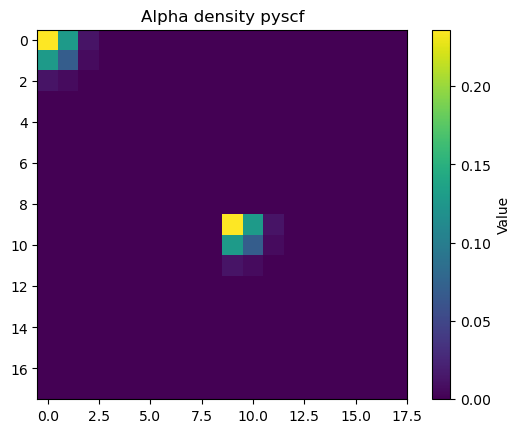

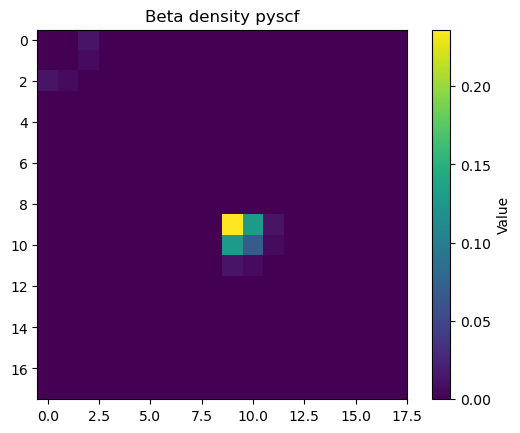

In [12]:
mol = gto.M(
    atom=f"  {element_1} 0 0 0; {element_2} 10 0 0;",
    spin=0,
    charge=0,
    basis=basis,
)

kin = mol.intor("int1e_kin")
vnuc = mol.intor("int1e_nuc")
overlap = mol.intor("int1e_ovlp")
eri = mol.intor("int2e")


mf = scf.UHF(
    mol,
)

dm_alpha, dm_beta = mf.get_init_guess()
dm_beta[:n_elec, :n_elec] = 0

dm = (dm_alpha, dm_beta)
mf.kernel(dm)

plot_map(dm_alpha, title="Alpha density pyscf")
plot_map(dm_beta, title="Beta density pyscf")

With the regular core guess

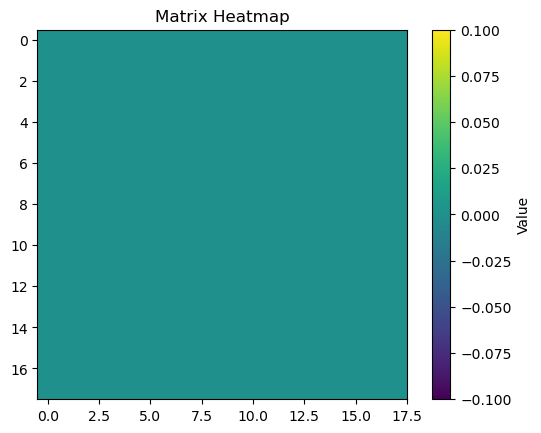

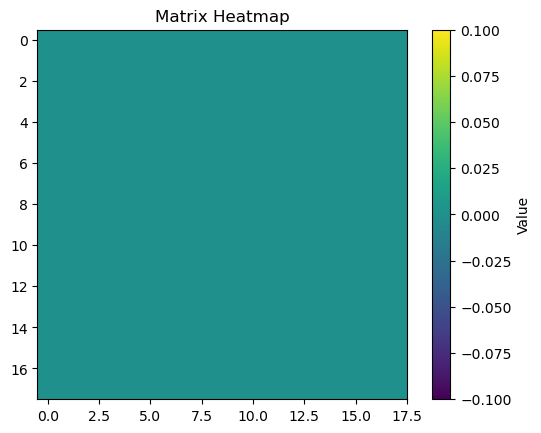

In [13]:
context = CSUHFContext(overlap, kin, vnuc, eri, n_electrons=n_elec, max_iter=1)

CS_UHF_results = CS_UHF(context)

plot_map(CS_UHF_results.P_guess_alpha.real)
plot_map(CS_UHF_results.P_guess_beta.real)

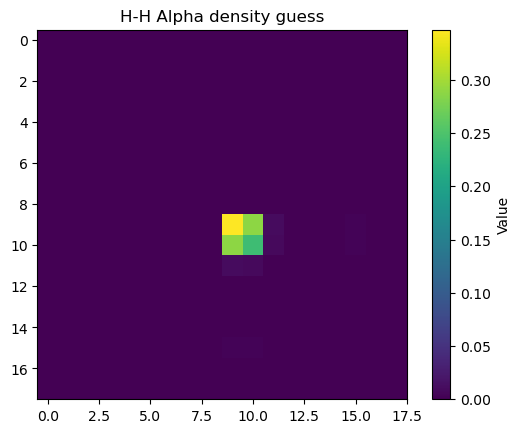

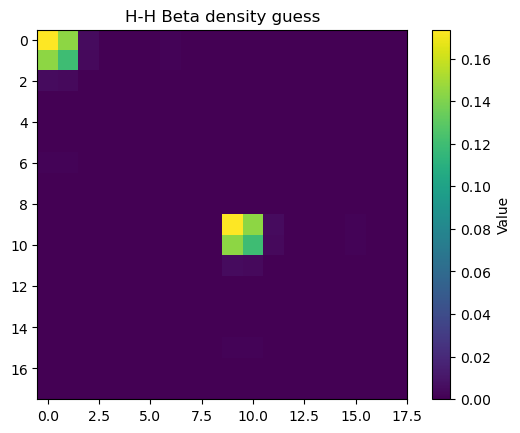

In [14]:
context = CSUHFContext(
    overlap,
    kin,
    vnuc,
    eri,
    n_electrons=n_elec,
    break_symm=True,
    max_iter=50,
    p_guess="RHF",
    
)

CS_UHF_results = CS_UHF(context)

plot_map(
    CS_UHF_results.P_guess_alpha.real,
    title=f"{element_1}-{element_2} Alpha density guess",
)
plot_map(
    CS_UHF_results.P_guess_beta.real,
    title=f"{element_1}-{element_2} Beta density guess",
)

In [15]:
print(CS_UHF_results.n_alpha)

1.0000000000000024


And the final densities:

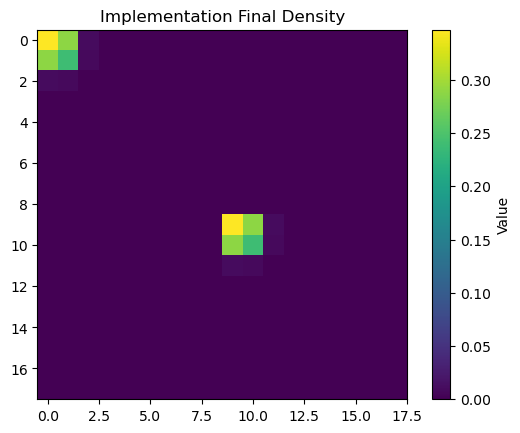

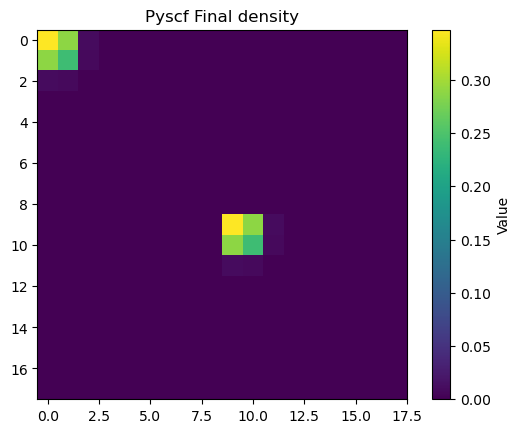

2.0000000000000027
1.9999999999999993


In [16]:
plot_map(CS_UHF_results.P_total.real, title="Implementation Final Density")
plot_map(mf.make_rdm1()[0] + mf.make_rdm1()[1], title="Pyscf Final density")
print(np.trace(CS_UHF_results.P_total.real @ CS_UHF_results.context.S))
print(np.trace((mf.make_rdm1()[0] + mf.make_rdm1()[1]) @ CS_UHF_results.context.S))

## Final dissociation curves
Here we can see the final dissociation curves using this `guess+bsymm` approach. It can be seen that even though in cases such as $HF$ the results are different to the pyscf ones, in both cases convergence is not achieved at longer distances. However, while pyscf seems to oscillate between the RHF and UHF, the implemented UHF presents the expected UHF tendency (even though it is not converged at these points).

In [17]:
Imp_RHF_eners = np.zeros_like(distances)
Imp_RHF_eners_core_guess = np.zeros_like(distances)

for i, dist in enumerate(distances):
    mol = gto.M(
        atom=f"  {element_1} 0 0 0; {element_2} {dist} 0 0",
        spin=0,
        charge=0,
        basis=basis,
    )

    kin = mol.intor("int1e_kin")
    vnuc = mol.intor("int1e_nuc")
    overlap = mol.intor("int1e_ovlp")
    eri = mol.intor("int2e")

    context = CSUHFContext(
        overlap,
        kin,
        vnuc,
        eri,
        n_electrons=n_elec,
        p_guess="RHF",
        break_symm=True,
        max_iter=200,
        _eigensolver = 'eigh'
    )

    CS_UHF_results = CS_UHF(context)
    print({dist}, CS_UHF_results.converged)
    Imp_RHF_eners[i] = CS_UHF_results.E_UHF.real


{np.float64(0.3)} True
{np.float64(0.8033898305084746)} True
{np.float64(1.306779661016949)} True
{np.float64(1.8101694915254236)} True
{np.float64(2.313559322033898)} True
{np.float64(2.8169491525423727)} True
{np.float64(3.320338983050847)} True
{np.float64(3.8237288135593213)} True
{np.float64(4.327118644067796)} True
{np.float64(4.830508474576271)} True
{np.float64(5.3338983050847455)} True
{np.float64(5.837288135593219)} True
{np.float64(6.340677966101694)} True
{np.float64(6.844067796610169)} True
{np.float64(7.347457627118643)} True
{np.float64(7.850847457627117)} True
{np.float64(8.354237288135593)} True
{np.float64(8.857627118644068)} True
{np.float64(9.361016949152543)} True
{np.float64(9.864406779661017)} True
{np.float64(10.367796610169492)} True
{np.float64(10.871186440677965)} True
{np.float64(11.37457627118644)} True
{np.float64(11.877966101694915)} True
{np.float64(12.38135593220339)} True
{np.float64(12.884745762711864)} True
{np.float64(13.388135593220339)} True
{np.f

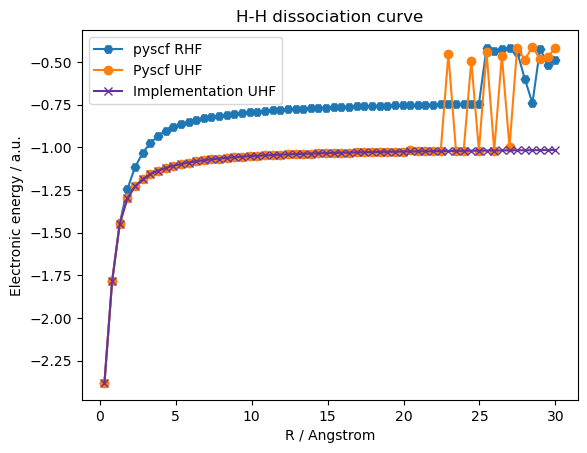

In [18]:
plt.plot(distances, RHF_eners, label="pyscf RHF", marker="H")
plt.plot(distances, UHF_eners, label="Pyscf UHF", marker="o")
plt.plot(
    distances, Imp_RHF_eners, label="Implementation UHF", marker="x", c="rebeccapurple"
)
plt.title(f"{element_1}-{element_2} dissociation curve")
plt.xlabel("R / Angstrom")
plt.ylabel("Electronic energy / a.u.")
plt.legend()
plt.show()

In [19]:
print(repr(UHF_eners))

array([-2.37960889, -1.78557279, -1.44785669, -1.29909141, -1.22888611,
       -1.18680684, -1.15809707, -1.13707247, -1.1209654 , -1.10821884,
       -1.09787918, -1.0893234 , -1.08212622, -1.07598777, -1.07069045,
       -1.06607247, -1.06201101, -1.05841118, -1.05519852, -1.05231374,
       -1.0497091 , -1.04734567, -1.04519144, -1.04321979, -1.04140847,
       -1.03973869, -1.03819446, -1.03676216, -1.03543003, -1.03418792,
       -1.03302701, -1.03193958, -1.03091887, -1.02995892, -1.02905448,
       -1.02820084, -1.02739386, -1.02662981, -1.02590535, -1.02521749,
       -1.01764761, -1.02394098, -1.02334767, -1.02278159, -1.02212887,
       -0.45615497, -1.02122912, -1.02075512, -0.49437563, -1.01986446,
       -0.44327539, -1.01904285, -0.46584607, -0.99797173, -0.41680714,
       -0.48682912, -0.4126417 , -0.48418253, -0.46969974, -0.42020237])
